<p style="font-family: Cambria; text-align: center; font-size: 48px;"> ML Model For Income Prediction - Final Presentation

<p style="font-family: Cambria; font-size: 22px;"><b>Importing the necessary Packages

In [314]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import ttest_ind, chi2_contingency  # For T-test and Chi-Square test
from ucimlrepo import fetch_ucirepo 
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import OneHotEncoder
from scipy.stats import skew
from scipy.stats.mstats import winsorize
from sklearn.preprocessing import StandardScaler
from tabulate import tabulate
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import LabelEncoder


In [315]:
# Enable future behavior explicitly
pd.set_option('future.no_silent_downcasting', True)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [316]:
# fetch dataset 
adult = fetch_ucirepo(id=2) 
# data (as pandas dataframes) 
X = adult.data.features 
y = adult.data.targets 
# Merge features and target using the index
df = X.join(y)

<p style="font-family: Cambria; font-size: 22px;"><b>DATA CLEANING

In [318]:
# Clean 'income' column
df['income'] = df['income'].str.strip().str.replace('.', '', regex=False)

In [319]:
income_counts = df['income'].value_counts()
print(income_counts)

income
<=50K    37155
>50K     11687
Name: count, dtype: int64


In [320]:
 for col in df:
        print(f"Unique values in '{col}':")
        print(df[col].unique())
        print("-" * 40)

Unique values in 'age':
[39 50 38 53 28 37 49 52 31 42 30 23 32 40 34 25 43 54 35 59 56 19 20 45
 22 48 21 24 57 44 41 29 18 47 46 36 79 27 67 33 76 17 55 61 70 64 71 68
 66 51 58 26 60 90 75 65 77 62 63 80 72 74 69 73 81 78 88 82 83 84 85 86
 87 89]
----------------------------------------
Unique values in 'workclass':
['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov' '?'
 'Self-emp-inc' 'Without-pay' 'Never-worked' nan]
----------------------------------------
Unique values in 'fnlwgt':
[ 77516  83311 215646 ... 173449  89686 350977]
----------------------------------------
Unique values in 'education':
['Bachelors' 'HS-grad' '11th' 'Masters' '9th' 'Some-college' 'Assoc-acdm'
 'Assoc-voc' '7th-8th' 'Doctorate' 'Prof-school' '5th-6th' '10th'
 '1st-4th' 'Preschool' '12th']
----------------------------------------
Unique values in 'education-num':
[13  9  7 14  5 10 12 11  4 16 15  3  6  2  1  8]
----------------------------------------
Unique values in 'marital-status

In [321]:
# saving a copy of the original data frame to compare later
df_original=df

In [322]:
df.isnull().sum()

age                 0
workclass         963
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
income              0
dtype: int64

In [323]:
# work class,occupation and native-country has null values 

In [324]:
# Replace '?' and blanks with NaN
df.replace(['?', ' '], np.nan, inplace=True)

In [325]:
df['workclass'] = df.groupby(['education'])['workclass'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

In [326]:
# Then, fill NaN values in 'occupation' based on the updated 'workclass' and 'education'
df['occupation'] = df.groupby(['workclass', 'education'])['occupation'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

In [327]:
df['occupation'] = df.groupby(['education','income'])['occupation'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

In [328]:
df['native-country'] = df['native-country'].fillna(df['native-country'].mode()[0])

In [329]:
# Handling the country name corrections

df['native-country'].replace({'Hong':'Hongkong','Trinadad&Tobago':'Trinidad and Tobago','Holand-Netherlands':'Netherlands','South':'South Korea'},inplace=True)

/var/folders/3h/whs2sn8x5652t26yd193_w140000gn/T/ipykernel_6301/1823592180.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['native-country'].replace({'Hong':'Hongkong','Trinadad&Tobago':'Trinidad and Tobago','Holand-Netherlands':'Netherlands','South':'South Korea'},inplace=True)


In [330]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

In [331]:
df.dtypes

age                int64
workclass         object
fnlwgt             int64
education         object
education-num      int64
marital-status    object
occupation        object
relationship      object
race              object
sex               object
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country    object
income            object
dtype: object

<p style="font-family: Cambria; font-size: 22px;"><b> Outlier handling

 Handling the Numeric columns - age,work hours per week and net captial

In [334]:
df['income'] = df['income'].replace({'<=50K': 0, '>50K': 1})
df['income'] = df['income'].astype(int)  # Convert to integer
df_numeric = df[['age','fnlwgt','education-num','capital-gain', 'capital-loss', 'hours-per-week','income']]

In [335]:
df_numeric.corr()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,income
age,1.000000,-0.076628,0.030940,0.077229,0.056944,0.071558,0.230369
fnlwgt,-0.076628,1.000000,-0.038761,-0.003706,-0.004366,-0.013519,-0.006339
education-num,0.030940,-0.038761,1.000000,0.125146,0.080972,0.143689,0.332613
capital-gain,0.077229,-0.003706,0.125146,1.000000,-0.031441,0.082157,0.223013
capital-loss,0.056944,-0.004366,0.080972,-0.031441,1.000000,0.054467,0.147554
hours-per-week,0.071558,-0.013519,0.143689,0.082157,0.054467,1.000000,0.227687
income,0.230369,-0.006339,0.332613,0.223013,0.147554,0.227687,1.000000


#### Dropping Fnlwgt column(don't contribute in the prediction model) as negatively correlated to the income target column.

# checking the distribution of age column

<Axes: xlabel='age', ylabel='Count'>

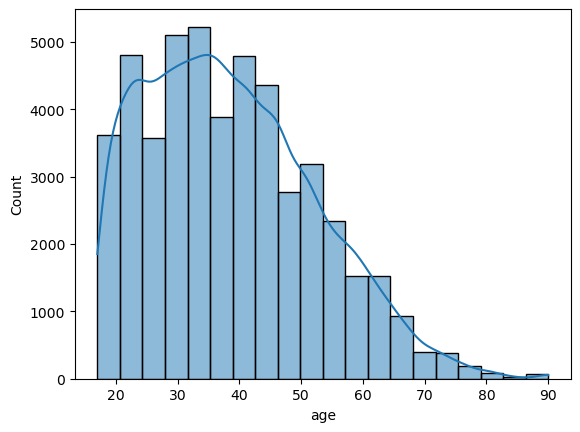

In [338]:
sns.histplot(data=df,x='age',kde=True,bins=20)

distribution is right-skewed (positively skewed) with a long tail extending toward higher ages. The distribution appears to peak around age 35-40 and then gradually decreases.

# checking the outliers in age column

<Axes: xlabel='age'>

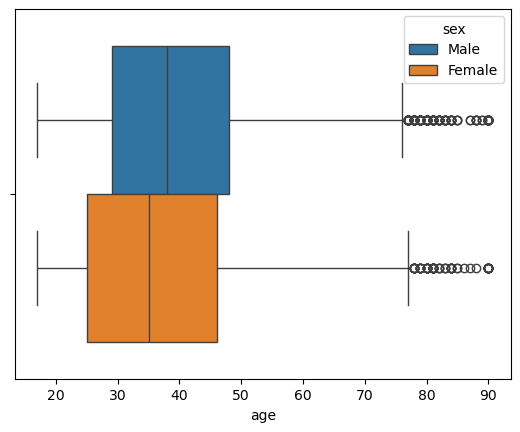

In [341]:
sns.boxplot(data=df,x='age',hue='sex')

#### Log trasformation to change the distribution to Normal distribution

Logarithmic transformation - Most commonly used for age data and right-skewed distributions

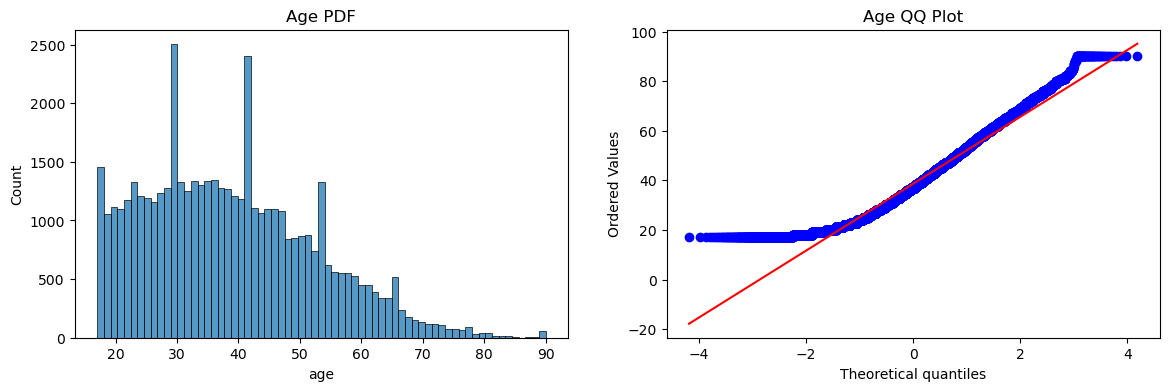

In [344]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.histplot(df['age'])
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(df['age'], dist="norm", plot=plt)
plt.title('Age QQ Plot')

plt.show()

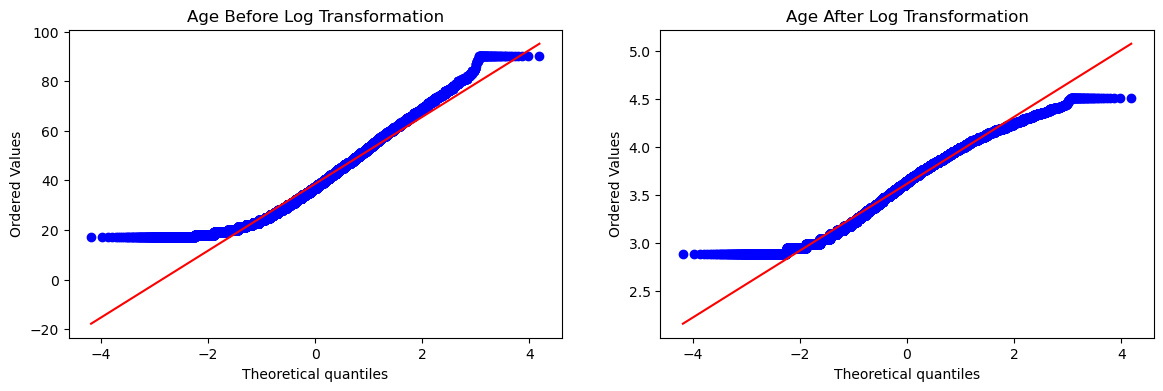

In [345]:
df['age_log'] = np.log1p(df['age'])

# QQ Plot before and after log transformation
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(df['age'], dist="norm", plot=plt)
plt.title("Age Before Log Transformation")

plt.subplot(122)
stats.probplot(df['age_log'], dist="norm", plot=plt)
plt.title("Age After Log Transformation")

plt.show()

In [346]:
print("Skewness before log transformation:", skew(df['age']))
print("Skewness after log transformation:", skew(df['age_log']))

Skewness before log transformation: 0.5575631924658626
Skewness after log transformation: -0.11374478357768275


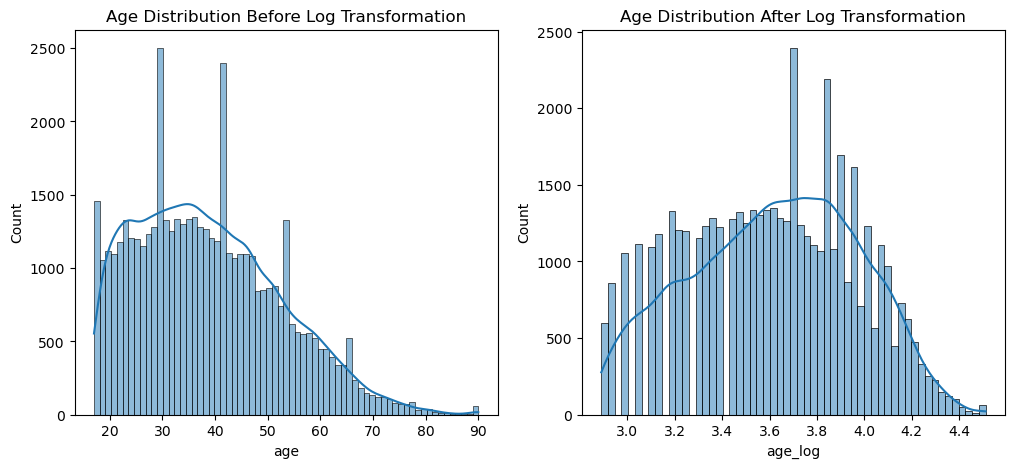

In [347]:
plt.figure(figsize=(12,5))
plt.subplot(121)
sns.histplot(df['age'], kde=True)
plt.title("Age Distribution Before Log Transformation")

plt.subplot(122)
sns.histplot(df['age_log'], kde=True)
plt.title("Age Distribution After Log Transformation")

plt.show()

<Axes: xlabel='hours-per-week', ylabel='Count'>

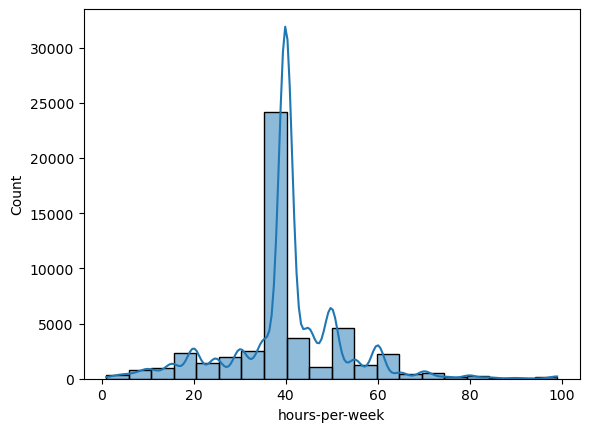

In [348]:
sns.histplot(data=df,x='hours-per-week',kde=True,bins=20)

<Axes: xlabel='hours-per-week'>

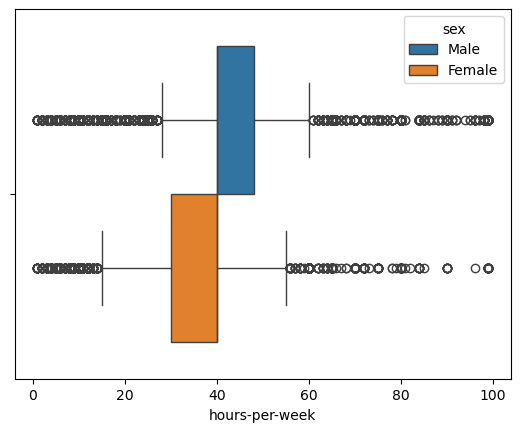

In [349]:
sns.boxplot(data=df,x='hours-per-week',hue='sex')

# Checking the count of records greater than 60,70 and 80 per weeek

In [351]:
print(f"Values > 60: {(df['hours-per-week'] > 60).sum()}")
print(f"Values > 70: {(df['hours-per-week'] > 70).sum()}")
print(f"Values > 80: {(df['hours-per-week'] > 80).sum()}")
print (f"Values < 20: {(df['hours-per-week'] <20).sum()}")

Values > 60: 1676
Values > 70: 774
Values > 80: 318
Values < 20: 2591


In [352]:
# Assuming df is your DataFrame and 'hours-per-week' is the column
df['hours-per-week-wins'] = winsorize(df['hours-per-week'], limits=[0.01, 0.01])

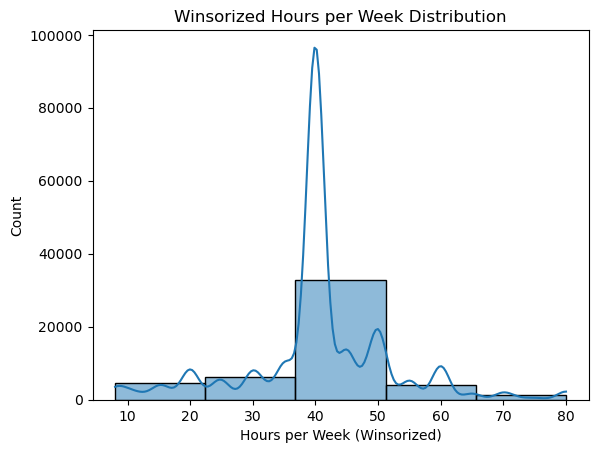

In [353]:
sns.histplot(df['hours-per-week-wins'], kde=True,bins=5)
plt.xlabel('Hours per Week (Winsorized)')
plt.ylabel('Count')
plt.title('Winsorized Hours per Week Distribution')
plt.show()

Winsorized Distribution: Cleaner & Statistically Stable
The sharp spike at 40 hours/week (the mode) is preserved. The long tails have been effectively suppressed, especially on the right side, without removing data. The KDE plot is smoother and more trustworthy for modeling or descriptive analysis.

<p style="font-family: Cambria; font-size: 22px;"><b> Data Standardization 

In [356]:
scaler = StandardScaler()
df['hours-per-week-wins-scaled'] = scaler.fit_transform(df[['hours-per-week-wins']])

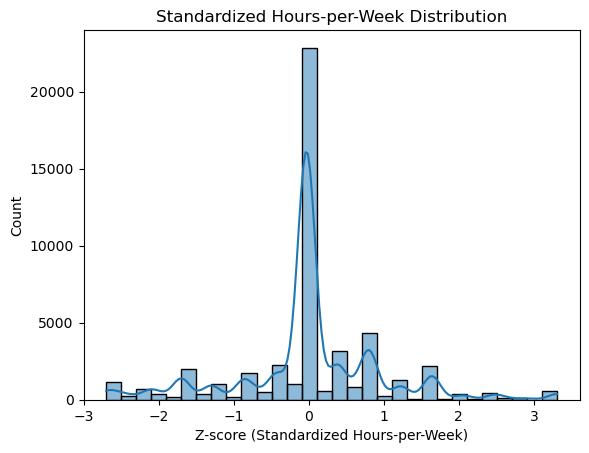

In [357]:
sns.histplot(df['hours-per-week-wins-scaled'], bins=30, kde=True)
plt.title('Standardized Hours-per-Week Distribution')
plt.xlabel('Z-score (Standardized Hours-per-Week)')
plt.ylabel('Count')
plt.show()

In [358]:
df['hours-per-week-wins-scaled'].skew()

0.01644448521771608

In [359]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,age_log,hours-per-week-wins,hours-per-week-wins-scaled
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0,3.688879,40,-0.031207
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0,3.931826,13,-2.286420
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0,3.663562,40,-0.031207
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,0,3.988984,40,-0.031207
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,0,3.367296,40,-0.031207


In [360]:
df.drop(['hours-per-week'], axis=1, inplace=True)

In [361]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,native-country,income,age_log,hours-per-week-wins,hours-per-week-wins-scaled
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,United-States,0,3.688879,40,-0.031207
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,United-States,0,3.931826,13,-2.286420
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,United-States,0,3.663562,40,-0.031207
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,United-States,0,3.988984,40,-0.031207
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,Cuba,0,3.367296,40,-0.031207


In [362]:
df.rename(columns={'hours-per-week-wins-scaled': 'hours-per-week'}, inplace=True)

In [363]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,native-country,income,age_log,hours-per-week-wins,hours-per-week
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,United-States,0,3.688879,40,-0.031207
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,United-States,0,3.931826,13,-2.286420
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,United-States,0,3.663562,40,-0.031207
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,United-States,0,3.988984,40,-0.031207
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,Cuba,0,3.367296,40,-0.031207


In [364]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'native-country', 'income', 'age_log',
       'hours-per-week-wins', 'hours-per-week'],
      dtype='object')

#### This z-score is very close to 0, indicating that the corresponding hours-per-week value is extremely close to the mean of the distribution.

# Creating a Net Capital Gain/Loss Column

In [367]:
df['capital_net'] = df['capital-gain'] - df['capital-loss']

#### Dropping capital-gain and capital-loss snice combined in to capital_net.

In [369]:
df.drop(['fnlwgt', 'capital-gain', 'capital-loss'], axis=1, inplace=True)

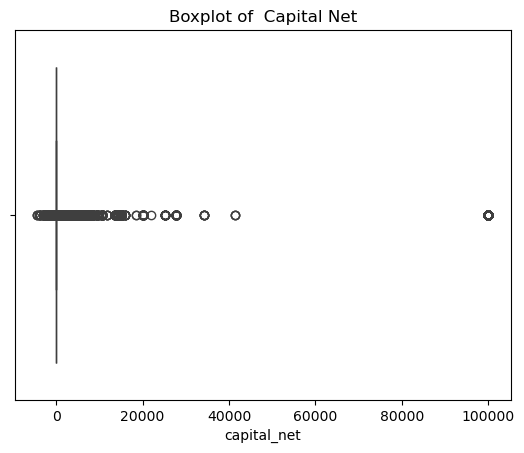

In [370]:
#checking the outliers
sns.boxplot(x=df['capital_net'])  
plt.title("Boxplot of  Capital Net")
plt.show()

# Two Methods of treating the outliers in Capital_net column

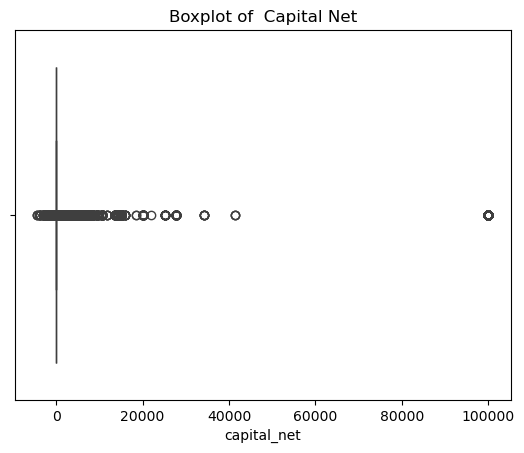

In [372]:
#checking the outliers
sns.boxplot(x=df['capital_net'])  
plt.title("Boxplot of  Capital Net")
plt.show()

In [373]:
def analyze_outliers(df, columns, income_col='income'):
    results = {}
    total_rows = len(df)
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outlier_mask = (df[col] < lower_bound) | (df[col] > upper_bound)
        outliers = df[outlier_mask]
        count_by_income = outliers[income_col].value_counts().to_dict()
        total_outliers = outlier_mask.sum()
        percent_outliers = (total_outliers / total_rows) * 100
        results[col] = {
            'total_outliers': total_outliers,
            '%_Outliers': round(percent_outliers, 2),
            '<=50K': count_by_income.get('<=50K', 0),
            '>50K': count_by_income.get('>50K', 0),
            'lower_bound': round(lower_bound, 2),
            'upper_bound': round(upper_bound, 2)
        }
    return pd.DataFrame(results).T
# Specify columns to check
columns_to_check = ['capital_net']
outlier_summary = analyze_outliers(df, columns_to_check)
# Display table with headers
print(tabulate(outlier_summary.reset_index(), headers='keys', tablefmt='grid'))

+----+-------------+------------------+--------------+---------+--------+---------------+---------------+
|    | index       |   total_outliers |   %_Outliers |   <=50K |   >50K |   lower_bound |   upper_bound |
+====+=============+==================+==============+=========+========+===============+===============+
|  0 | capital_net |             6317 |        12.93 |       0 |      0 |             0 |             0 |
+----+-------------+------------------+--------------+---------+--------+---------------+---------------+


### Grouping the capital_net column as categorical variable 

In [375]:
df['net-capital-group'] = df['capital_net'].apply(lambda nc: 'Loss' if nc < 0 else 'Neutral' if nc == 0 else 'Gain')

In [376]:
df['net-capital-group'].value_counts()

net-capital-group
Neutral    42525
Gain        4035
Loss        2282
Name: count, dtype: int64

<p style="font-family: Cambria; font-size: 22px;"><b>Data Transformation Methods:

#### Using the Yeo-Johnson Transformation on the net-capital column as it works with zero and negative values.

In [379]:
# Initialize transformer
pt = PowerTransformer(method='yeo-johnson', standardize=False)

# Apply Yeo-Johnson to 'net-capital' and store in new column
df['net-capital-yeojohnson'] = pt.fit_transform(df[['capital_net']])

### Below is the Box plot visualization before and after applying Yeo Johnson Transformation

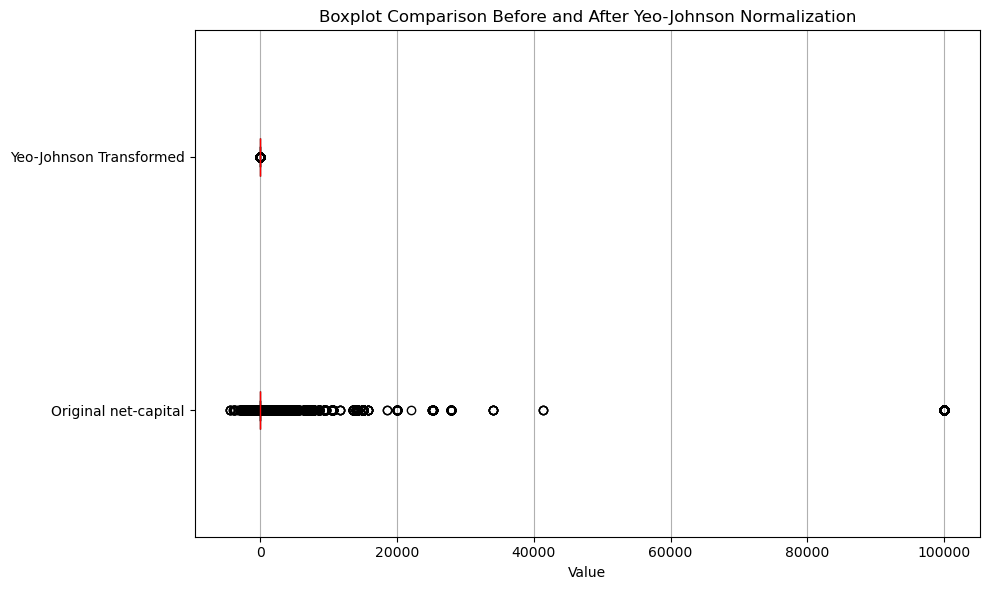

In [381]:
df.loc[0, 'capital_net'] = 99999   # Extreme positive outlier
df.loc[1, 'capital_net'] = -4356   # Extreme negative outlier

# Apply Yeo-Johnson transformation
pt = PowerTransformer(method='yeo-johnson')
df['net-capital-yeojohnson'] = pt.fit_transform(df['capital_net'].values.reshape(-1, 1))

# Updated: Use tick_labels instead of labels
plt.figure(figsize=(10, 6))
plt.boxplot(
    [df['capital_net'], df['net-capital-yeojohnson']],
    vert=False,
    tick_labels=['Original net-capital', 'Yeo-Johnson Transformed'],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue'),
    medianprops=dict(color='red')
)

plt.title('Boxplot Comparison Before and After Yeo-Johnson Normalization')
plt.xlabel('Value')
plt.grid(axis='x')
plt.tight_layout()
plt.show()

In [382]:
df.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'sex', 'native-country', 'income',
       'age_log', 'hours-per-week-wins', 'hours-per-week', 'capital_net',
       'net-capital-group', 'net-capital-yeojohnson'],
      dtype='object')

In [383]:
# Define mapping dictionaries
marital_group = {
    'Never-married': 'Single',
    'Married-civ-spouse': 'Married',
    'Married-AF-spouse': 'Married',
    'Married-spouse-absent': 'Separated',
    'Separated': 'Separated',
    'Divorced': 'Separated',
    'Widowed': 'Widowed'
}

education_group = {
    'Preschool': 'Preschool',
    '1st-4th': 'Elementary School', '5th-6th': 'Elementary School',
    '7th-8th': 'Middle School',
    '9th': 'High School', '10th': 'High School', '11th': 'High School', '12th': 'High School', 'HS-grad': 'High School',
    'Some-college': 'Some College', 'Assoc-acdm': 'Associate degree', 'Assoc-voc': 'Associate degree',
    'Bachelors': 'Undergraduate',
    'Masters': 'Advanced Degree',
    'Doctorate': 'Advanced Degree', 'Prof-school': 'Advanced Degree'
}

# Apply replacements
df['marital-status'] = df['marital-status'].map(marital_group)
df['education'] = df['education'].map(education_group)

In [384]:
# Define category dictionaries
north_america = {'United-States': 'North America', 'Canada': 'North America', 'Mexico': 'North America'}
us_territories = {'Outlying-US(Guam-USVI-etc)': 'US Territories'}
asia = {
    'Philippines': 'Asia', 'India': 'Asia', 'China': 'Asia', 'Japan': 'Asia', 'Vietnam': 'Asia',
    'Taiwan': 'Asia', 'Thailand': 'Asia', 'South Korea': 'Asia', 'Cambodia': 'Asia', 'Hongkong': 'Asia',
    'Iran': 'Asia', 'Laos': 'Asia'
}
europe = {
    'Germany': 'Europe', 'England': 'Europe', 'Italy': 'Europe', 'France': 'Europe', 'Poland': 'Europe',
    'Portugal': 'Europe', 'Greece': 'Europe', 'Ireland': 'Europe', 'Hungary': 'Europe', 'Scotland': 'Europe',
    'Yugoslavia': 'Europe', 'Netherlands': 'Europe'
}
latin_america = {
    'Puerto-Rico': 'Latin America', 'Honduras': 'Latin America', 'Jamaica': 'Latin America',
    'Cuba': 'Latin America', 'Dominican-Republic': 'Latin America', 'Columbia': 'Latin America',
    'Guatemala': 'Latin America', 'Nicaragua': 'Latin America', 'Ecuador': 'Latin America',
    'Peru': 'Latin America', 'El-Salvador': 'Latin America', 'Trinidad and Tobago': 'Latin America',
    'Haiti': 'Latin America'
}

# Merge all dictionaries into one for mapping
country_group = {**north_america, **us_territories, **asia, **europe, **latin_america}

# Apply mapping to the DataFrame
df['region'] = df['native-country'].map(country_group).fillna('Other')

In [385]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# Assuming your dataframe is called df
# and you have 'native_country', 'region', and 'target' columns (e.g., 'income')

# 1. Chi-square test before grouping (native_country)
contingency_orig = pd.crosstab(df['native-country'], df['income'])
chi2_orig, p_orig, dof_orig, _ = chi2_contingency(contingency_orig)

# 2. Chi-square test after grouping (region)
contingency_grouped = pd.crosstab(df['region'], df['income'])
chi2_grouped, p_grouped, dof_grouped, _ = chi2_contingency(contingency_grouped)

# 3. Function to calculate Cramér's V
def cramers_v(chi2, n, k):
    return np.sqrt(chi2 / (n * (k - 1)))

n_orig = contingency_orig.sum().sum()
k_orig = min(contingency_orig.shape)
cramers_v_orig = cramers_v(chi2_orig, n_orig, k_orig)

n_grouped = contingency_grouped.sum().sum()
k_grouped = min(contingency_grouped.shape)
cramers_v_grouped = cramers_v(chi2_grouped, n_grouped, k_grouped)

# 4. Print results
print("=== Before Grouping (native-country) ===")
print(f"Chi-Square: {chi2_orig:.4f}, p-value: {p_orig:.4f}, df: {dof_orig}")
print(f"Cramér's V: {cramers_v_orig:.4f}")

print("\n=== After Grouping (region) ===")
print(f"Chi-Square: {chi2_grouped:.4f}, p-value: {p_grouped:.4f}, df: {dof_grouped}")
print(f"Cramér's V: {cramers_v_grouped:.4f}")

# Interpretation
if p_grouped < 0.05:
    print("\nRelationship remains statistically significant after grouping.")
else:
    print("\nRelationship is NOT statistically significant after grouping.")


=== Before Grouping (native-country) ===
Chi-Square: 451.4804, p-value: 0.0000, df: 40
Cramér's V: 0.0961

=== After Grouping (region) ===
Chi-Square: 142.5471, p-value: 0.0000, df: 4
Cramér's V: 0.0540

Relationship remains statistically significant after grouping.


In [386]:
# Define mapping dictionary
occupation_group = {
    'Exec-managerial': 'White-Collar', 'Prof-specialty': 'White-Collar', 'Tech-support': 'White-Collar',
    'Craft-repair': 'Blue-Collar', 'Machine-op-inspct': 'Blue-Collar', 'Handlers-cleaners': 'Blue-Collar',
    'Sales': 'Office-Admin', 'Adm-clerical': 'Office-Admin',
    'Farming-fishing': 'Labor', 'Transport-moving': 'Labor',
    'Priv-house-serv': 'Service', 'Protective-serv': 'Service', 'Other-service': 'Service',
    'Armed-Forces': 'Military'
}

# Apply replacements
df['occupation'] = df['occupation'].map(occupation_group).fillna('Other')

In [387]:
# Define mapping dictionary
workclass_group = {
    'Private': 'Private',
    'Self-emp-not-inc': 'Self-Employed', 'Self-emp-inc': 'Self-Employed',
    'Federal-gov': 'Government', 'Local-gov': 'Government', 'State-gov': 'Government',
    'Without-pay': 'Unemployed', 'Never-worked': 'Unemployed'
}

# Apply replacements
df['workclass'] = df['workclass'].map(workclass_group).fillna('Other')

In [388]:
df.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'sex', 'native-country', 'income',
       'age_log', 'hours-per-week-wins', 'hours-per-week', 'capital_net',
       'net-capital-group', 'net-capital-yeojohnson', 'region'],
      dtype='object')

In [389]:
df.dtypes

age                         int64
workclass                  object
education                  object
education-num               int64
marital-status             object
occupation                 object
relationship               object
race                       object
sex                        object
native-country             object
income                      int64
age_log                   float64
hours-per-week-wins         int64
hours-per-week            float64
capital_net                 int64
net-capital-group          object
net-capital-yeojohnson    float64
region                     object
dtype: object

<p style="font-family: Cambria; font-size: 22px;"><b> Encoding

In [ ]:
# Create ordinal encoder with ordered categories
encoder = OrdinalEncoder(categories=[['Preschool', 'Elementary School', 'Middle School', 
                                   'High School', 'Some College', 'Associate degree', 'Undergraduate', 
                                   'Graduate', 'Advanced Degree']])

# Fit and transform
df['education'] = encoder.fit_transform(df[['education']]).ravel()

In [391]:
encoder = OneHotEncoder(sparse_output=False)
marital_encoded = encoder.fit_transform(df[['marital-status']])

feature_names = encoder.get_feature_names_out(['marital-status'])
marital_df = pd.DataFrame(marital_encoded, columns=feature_names, index=df.index)


In [392]:
marital_df.head()

,marital-status_Married,marital-status_Separated,marital-status_Single,marital-status_Widowed
0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0
3,1.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0


In [393]:
df = pd.concat([df, marital_df], axis=1)
df = df.drop('marital-status', axis=1)

In [394]:
df.head(15)

,age,workclass,education,education-num,occupation,relationship,race,sex,native-country,income,age_log,hours-per-week-wins,hours-per-week,capital_net,net-capital-group,net-capital-yeojohnson,region,marital-status_Married,marital-status_Separated,marital-status_Single,marital-status_Widowed
0,39,Government,6.0,13,Office-Admin,Not-in-family,White,Male,United-States,0,3.688879,40,-0.031207,99999,Gain,8.178606,North America,0.0,0.0,1.0,0.0
1,50,Self-Employed,6.0,13,White-Collar,Husband,White,Male,United-States,0,3.931826,13,-2.286420,-4356,Neutral,-9.192809,North America,1.0,0.0,0.0,0.0
2,38,Private,3.0,9,Blue-Collar,Not-in-family,White,Male,United-States,0,3.663562,40,-0.031207,0,Neutral,0.046359,North America,0.0,1.0,0.0,0.0
3,53,Private,3.0,7,Blue-Collar,Husband,Black,Male,United-States,0,3.988984,40,-0.031207,0,Neutral,0.046359,North America,1.0,0.0,0.0,0.0
4,28,Private,6.0,13,White-Collar,Wife,Black,Female,Cuba,0,3.367296,40,-0.031207,0,Neutral,0.046359,Latin America,1.0,0.0,0.0,0.0
5,37,Private,8.0,14,White-Collar,Wife,White,Female,United-States,0,3.637586,40,-0.031207,0,Neutral,0.046359,North America,1.0,0.0,0.0,0.0
6,49,Private,3.0,5,Service,Not-in-family,Black,Female,Jamaica,0,3.912023,16,-2.035840,0,Neutral,0.046359,Latin America,0.0,1.0,0.0,0.0
7,52,Self-Employed,3.0,9,White-Collar,Husband,White,Male,United-States,1,3.970292,45,0.386425,0,Neutral,0.046359,North America,1.0,0.0,0.0,0.0
8,31,Private,8.0,14,White-Collar,Not-in-family,White,Female,United-States,1,3.465736,50,0.804058,14084,Gain,1.683799,North America,0.0,0.0,1.0,0.0
9,42,Private,6.0,13,White-Collar,Husband,White,Male,United-States,1,3.761200,40,-0.031207,5178,Gain,0.768668,North America,1.0,0.0,0.0,0.0


In [395]:
encoder = OneHotEncoder(sparse_output=False)
# Encode
workclass_encoded = encoder.fit_transform(df[['workclass']])
# Get new column names
feature_names = encoder.get_feature_names_out(['workclass'])
# Convert to DataFrame
workclass_df = pd.DataFrame(workclass_encoded, columns=feature_names, index=df.index)
# Add to original dataframe
df = pd.concat([df, workclass_df], axis=1)
# Drop original column
df = df.drop('workclass', axis=1)

In [396]:
df.head(5)

,age,education,education-num,occupation,relationship,race,sex,native-country,income,age_log,hours-per-week-wins,hours-per-week,capital_net,net-capital-group,net-capital-yeojohnson,region,marital-status_Married,marital-status_Separated,marital-status_Single,marital-status_Widowed,workclass_Government,workclass_Private,workclass_Self-Employed,workclass_Unemployed
0,39,6.0,13,Office-Admin,Not-in-family,White,Male,United-States,0,3.688879,40,-0.031207,99999,Gain,8.178606,North America,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1,50,6.0,13,White-Collar,Husband,White,Male,United-States,0,3.931826,13,-2.286420,-4356,Neutral,-9.192809,North America,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,38,3.0,9,Blue-Collar,Not-in-family,White,Male,United-States,0,3.663562,40,-0.031207,0,Neutral,0.046359,North America,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,53,3.0,7,Blue-Collar,Husband,Black,Male,United-States,0,3.988984,40,-0.031207,0,Neutral,0.046359,North America,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,28,6.0,13,White-Collar,Wife,Black,Female,Cuba,0,3.367296,40,-0.031207,0,Neutral,0.046359,Latin America,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [397]:
encoder = OneHotEncoder(sparse_output=False)
race_encoded = encoder.fit_transform(df[['race']])
# Get new column names
feature_names = encoder.get_feature_names_out(['race'])
# Convert to DataFrame
race_encoded_df = pd.DataFrame(race_encoded, columns=feature_names, index=df.index)
# Add to original dataframe
df = pd.concat([df, race_encoded_df], axis=1)
# Drop original column
df = df.drop('race', axis=1)

In [398]:
df.head()

,age,education,education-num,occupation,relationship,sex,native-country,income,age_log,hours-per-week-wins,hours-per-week,capital_net,net-capital-group,net-capital-yeojohnson,region,marital-status_Married,marital-status_Separated,marital-status_Single,marital-status_Widowed,workclass_Government,workclass_Private,workclass_Self-Employed,workclass_Unemployed,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White
0,39,6.0,13,Office-Admin,Not-in-family,Male,United-States,0,3.688879,40,-0.031207,99999,Gain,8.178606,North America,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,50,6.0,13,White-Collar,Husband,Male,United-States,0,3.931826,13,-2.286420,-4356,Neutral,-9.192809,North America,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,38,3.0,9,Blue-Collar,Not-in-family,Male,United-States,0,3.663562,40,-0.031207,0,Neutral,0.046359,North America,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,53,3.0,7,Blue-Collar,Husband,Male,United-States,0,3.988984,40,-0.031207,0,Neutral,0.046359,North America,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,28,6.0,13,White-Collar,Wife,Female,Cuba,0,3.367296,40,-0.031207,0,Neutral,0.046359,Latin America,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [399]:
encoder = OneHotEncoder(sparse_output=False)
sex_encoded = encoder.fit_transform(df[['sex']])
# Get column names
feature_names = encoder.get_feature_names_out(['sex'])
# Convert to DataFrame
sex_df = pd.DataFrame(sex_encoded, columns=feature_names, index=df.index)
# Add encoded columns
df = pd.concat([df, sex_df], axis=1)
# Drop original column
df = df.drop('sex', axis=1)

In [400]:
df.head()

,age,education,education-num,occupation,relationship,native-country,income,age_log,hours-per-week-wins,hours-per-week,capital_net,net-capital-group,net-capital-yeojohnson,region,marital-status_Married,marital-status_Separated,marital-status_Single,marital-status_Widowed,workclass_Government,workclass_Private,workclass_Self-Employed,workclass_Unemployed,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White,sex_Female,sex_Male
0,39,6.0,13,Office-Admin,Not-in-family,United-States,0,3.688879,40,-0.031207,99999,Gain,8.178606,North America,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,50,6.0,13,White-Collar,Husband,United-States,0,3.931826,13,-2.286420,-4356,Neutral,-9.192809,North America,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2,38,3.0,9,Blue-Collar,Not-in-family,United-States,0,3.663562,40,-0.031207,0,Neutral,0.046359,North America,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,53,3.0,7,Blue-Collar,Husband,United-States,0,3.988984,40,-0.031207,0,Neutral,0.046359,North America,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,28,6.0,13,White-Collar,Wife,Cuba,0,3.367296,40,-0.031207,0,Neutral,0.046359,Latin America,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [401]:
df.columns

Index(['age', 'education', 'education-num', 'occupation', 'relationship',
       'native-country', 'income', 'age_log', 'hours-per-week-wins',
       'hours-per-week', 'capital_net', 'net-capital-group',
       'net-capital-yeojohnson', 'region', 'marital-status_Married',
       'marital-status_Separated', 'marital-status_Single',
       'marital-status_Widowed', 'workclass_Government', 'workclass_Private',
       'workclass_Self-Employed', 'workclass_Unemployed',
       'race_Amer-Indian-Eskimo', 'race_Asian-Pac-Islander', 'race_Black',
       'race_Other', 'race_White', 'sex_Female', 'sex_Male'],
      dtype='object')

In [402]:
# Initialize the LabelEncoder
label_encoders = {}  # Dictionary to store label encoders for each column
columns_to_encode = ['relationship', 'occupation', 'region','net-capital-group']

for col in columns_to_encode:
    label_encoders[col] = LabelEncoder()  # Create a label encoder for the column
    df[col] = label_encoders[col].fit_transform(df[col])  # Apply label encoding

# Now df contains label-encoded values for 'relationship', 'occupation', and 'region'

In [403]:
df.columns

Index(['age', 'education', 'education-num', 'occupation', 'relationship',
       'native-country', 'income', 'age_log', 'hours-per-week-wins',
       'hours-per-week', 'capital_net', 'net-capital-group',
       'net-capital-yeojohnson', 'region', 'marital-status_Married',
       'marital-status_Separated', 'marital-status_Single',
       'marital-status_Widowed', 'workclass_Government', 'workclass_Private',
       'workclass_Self-Employed', 'workclass_Unemployed',
       'race_Amer-Indian-Eskimo', 'race_Asian-Pac-Islander', 'race_Black',
       'race_Other', 'race_White', 'sex_Female', 'sex_Male'],
      dtype='object')

In [404]:
df.head(15)

,age,education,education-num,occupation,relationship,native-country,income,age_log,hours-per-week-wins,hours-per-week,capital_net,net-capital-group,net-capital-yeojohnson,region,marital-status_Married,marital-status_Separated,marital-status_Single,marital-status_Widowed,workclass_Government,workclass_Private,workclass_Self-Employed,workclass_Unemployed,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White,sex_Female,sex_Male
0,39,6.0,13,3,1,United-States,0,3.688879,40,-0.031207,99999,0,8.178606,3,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,50,6.0,13,5,0,United-States,0,3.931826,13,-2.286420,-4356,2,-9.192809,3,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2,38,3.0,9,0,1,United-States,0,3.663562,40,-0.031207,0,2,0.046359,3,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,53,3.0,7,0,0,United-States,0,3.988984,40,-0.031207,0,2,0.046359,3,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,28,6.0,13,5,5,Cuba,0,3.367296,40,-0.031207,0,2,0.046359,2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
5,37,8.0,14,5,5,United-States,0,3.637586,40,-0.031207,0,2,0.046359,3,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
6,49,3.0,5,4,1,Jamaica,0,3.912023,16,-2.035840,0,2,0.046359,2,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
7,52,3.0,9,5,0,United-States,1,3.970292,45,0.386425,0,2,0.046359,3,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
8,31,8.0,14,5,1,United-States,1,3.465736,50,0.804058,14084,0,1.683799,3,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
9,42,6.0,13,5,0,United-States,1,3.761200,40,-0.031207,5178,0,0.768668,3,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


In [405]:

data=df[[ 'education', 'education-num', 'occupation', 'relationship',
       'hours-per-week', 'native-country', 'income', 'age_log',
       'hours-per-week-wins', 'net-capital-group',
       'net-capital-yeojohnson', 'region',
       'marital-status_Married', 'marital-status_Separated',
       'marital-status_Single', 'marital-status_Widowed',
       'workclass_Government', 'workclass_Private', 'workclass_Self-Employed',
       'workclass_Unemployed', 'race_Amer-Indian-Eskimo',
       'race_Asian-Pac-Islander', 'race_Black', 'race_Other', 'race_White',
       'sex_Female', 'sex_Male']]


In [406]:
data=df[[ 'education', 'education-num', 'occupation', 'relationship',
       'hours-per-week', 'native-country', 'income', 'age_log',
       'hours-per-week-wins',  'net-capital-group',
       'net-capital-yeojohnson', 'region',
       'marital-status_Married', 'marital-status_Separated',
       'marital-status_Single', 'marital-status_Widowed',
       'workclass_Government', 'workclass_Private', 'workclass_Self-Employed',
       'workclass_Unemployed', 'race_Amer-Indian-Eskimo',
       'race_Asian-Pac-Islander', 'race_Black', 'race_Other', 'race_White',
       'sex_Female', 'sex_Male']].copy()

# Rename columns safely
data = data.rename(columns={
    'age_log': 'age',
    'net-capital-yeojohnson': 'capital_net'
})

In [407]:
data.columns

Index(['education', 'education-num', 'occupation', 'relationship',
       'hours-per-week', 'native-country', 'income', 'age',
       'hours-per-week-wins', 'net-capital-group', 'capital_net', 'region',
       'marital-status_Married', 'marital-status_Separated',
       'marital-status_Single', 'marital-status_Widowed',
       'workclass_Government', 'workclass_Private', 'workclass_Self-Employed',
       'workclass_Unemployed', 'race_Amer-Indian-Eskimo',
       'race_Asian-Pac-Islander', 'race_Black', 'race_Other', 'race_White',
       'sex_Female', 'sex_Male'],
      dtype='object')

In [497]:
df1= data[['education', 'education-num', 'occupation', 'relationship',
       'hours-per-week', 'income', 'age',
       'hours-per-week-wins', 'capital_net',
       'region', 'marital-status_Married', 'marital-status_Separated',
       'marital-status_Single', 'marital-status_Widowed',
       'workclass_Government', 'workclass_Private', 'workclass_Self-Employed',
       'workclass_Unemployed', 'race_Amer-Indian-Eskimo',
       'race_Asian-Pac-Islander', 'race_Black', 'race_Other', 'race_White'
       ]].copy()

<p style="font-family: Cambria; text-align: center; font-size: 48px;"> Building ML Model on  Dataframe

<p style="font-family: Cambria; font-size: 22px;"><b>
Model Building Using the prepared data, we trained several classification models:

* Logistic Regression
* Random Forest
* SVM model
* XGBoost

We then evaluated and compared each model’s performance for predicting income.

# Split the dataset

In [501]:
# Splitting of X and Y 
X = df1.drop('income',axis=1)
y = df1['income']
print('shape of X and y respectively :', X.shape, y.shape)

shape of X and y respectively : (48842, 22) (48842,)


In [502]:
# Splitting of training and testing dataset
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
print('shape of X and y respectively (train) :', X_train.shape, y_train.shape)
print('shape of X and y respectively (test) :', X_test.shape, y_test.shape)

shape of X and y respectively (train) : (32724, 22) (32724,)
shape of X and y respectively (test) : (16118, 22) (16118,)


<p style="font-family: Cambria; text-align: center; font-size: 48px;">Logistic regression

Logistic Regression
Training Score: 0.8289634519007456
Testing Score: 0.8289634519007456
              precision    recall  f1-score   support

           0       0.86      0.92      0.89     12204
           1       0.68      0.52      0.59      3914

    accuracy                           0.82     16118
   macro avg       0.77      0.72      0.74     16118
weighted avg       0.81      0.82      0.82     16118



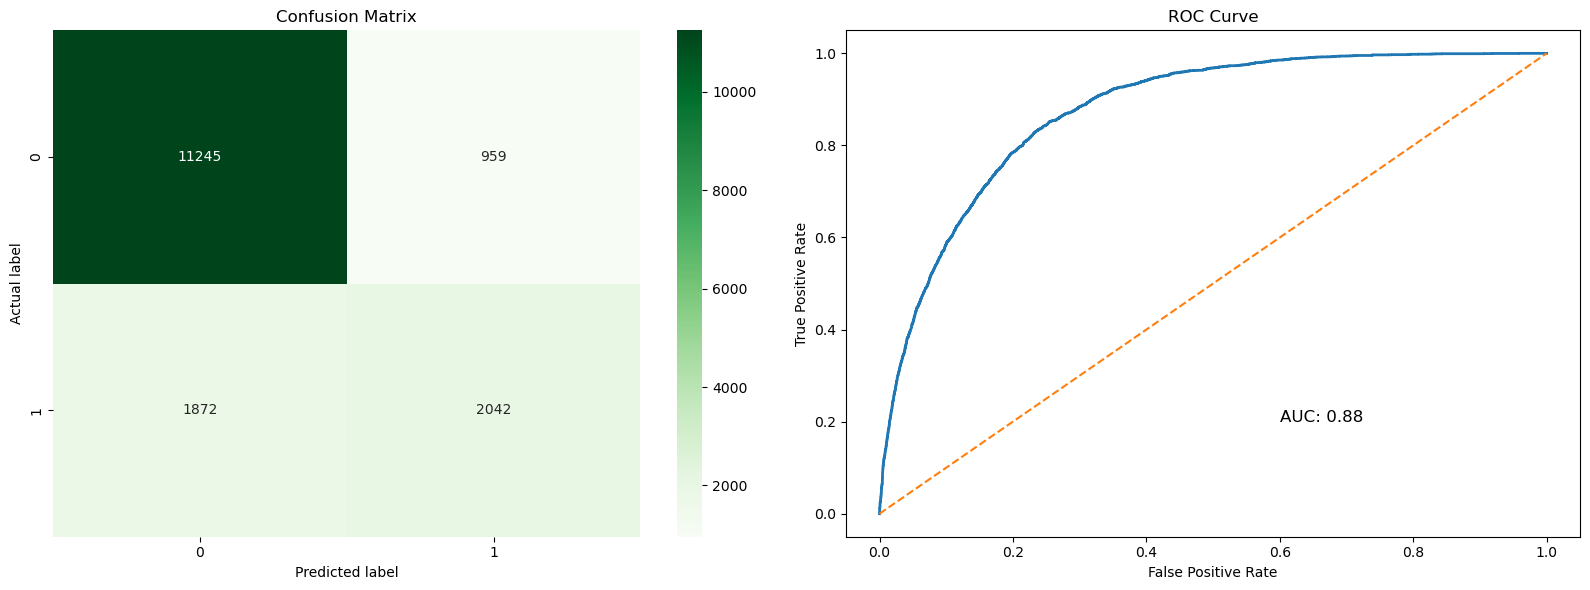


Test Set Performance of Logistic Regression:
Accuracy : 0.8244
Precision: 0.6804
Recall   : 0.5217
F1 Score : 0.5906
ROC AUC  : 0.8752
Confusion Matrix:
[[11245   959]
 [ 1872  2042]]


In [556]:
print('Logistic Regression')

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

model =  LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
Y_pred = model.predict(X_test)
score = model.score(X_train, y_train)
print('Training Score:', score)
score_log = model.score(X_test, y_test)
print('Testing Score:', score)
from sklearn.metrics import classification_report
print(classification_report(y_test,Y_pred))

from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

# Create subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ------------------ Confusion Matrix ------------------
cm = confusion_matrix(y_test, Y_pred)

sns.heatmap(pd.DataFrame(cm), annot=True, fmt='g', cmap='Greens', ax=axes[0])

axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted label')
axes[0].set_ylabel('Actual label')

# ------------------ ROC Curve ------------------
y_probabilities = model.predict_proba(X_test)[:, 1]
fpr, tpr, threshold = roc_curve(y_test, y_probabilities)

axes[1].plot(fpr, tpr, linewidth=2)
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')

# Add AUC text
auc_score = roc_auc_score(y_test, y_probabilities)
axes[1].text(0.6, 0.2, f'AUC: {auc_score:.2f}', fontsize=12)

# Adjust layout
plt.tight_layout()
plt.show()

# Generate predictions
y_pred = Y_pred
y_proba = y_probabilities

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("\nTest Set Performance of Logistic Regression:")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")

cm = confusion_matrix(y_test, Y_pred)
print("Confusion Matrix:")
print(cm)


<p style="font-family: Cambria; font-size: 22px;"><b> Logistic Regression

<p style="font-family: Cambria; font-size: 22px;"><b> Model Performance Summary:
    
* Accuracy (82.44%): The model correctly classifies income for over 82% of individuals in the test set.
* Precision for >50K (68.04%): When predicting high income, it is correct about 68% of the time.
* Recall for >50K (52.17%): It identifies around 52% of actual high earners, missing nearly half.
* F1 Score (59.06%): Indicates moderate balance between precision and recall.
* ROC AUC (87.52%): Shows strong ability to distinguish between income classes.

Confusion Matrix Interpretation:
    
* True Negatives (11245): Low-income individuals correctly classified.
* True Positives (2042): High-income individuals correctly identified.
* False Positives (959): Some low earners incorrectly labeled as high income.
* False Negatives (1872): Many high earners missed by the model.

Key Insights:

* Good baseline model with stable performance.
* Lower recall indicates it misses a significant number of high earners.
* Works well when interpretability and simplicity are important

<p style="font-family: Cambria; text-align: center; font-size: 48px;"> RandomForestClassifier

Random Forest Classifier
Training Score: 0.8683535020168683
Testing Score: 0.8567440129048269
              precision    recall  f1-score   support

           0       0.87      0.95      0.91     12204
           1       0.79      0.56      0.66      3914

    accuracy                           0.86     16118
   macro avg       0.83      0.76      0.78     16118
weighted avg       0.85      0.86      0.85     16118



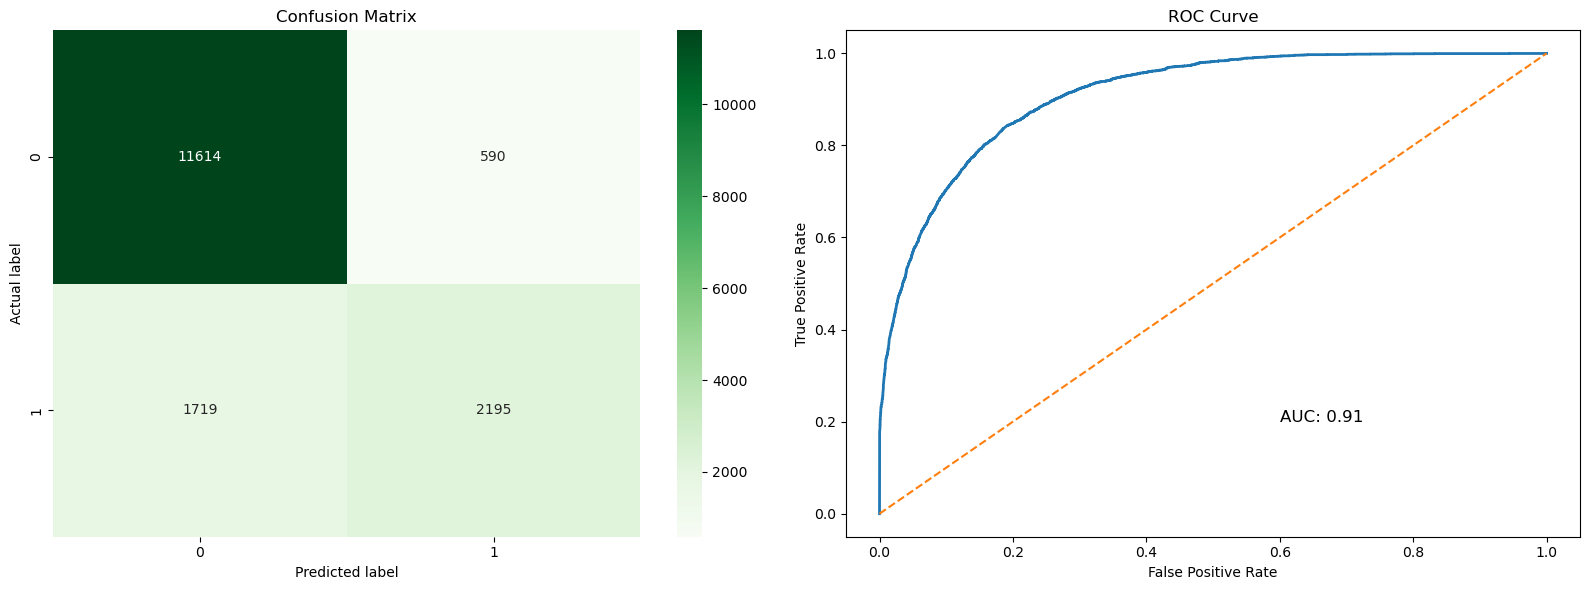


Test Set Performance of Random forest classifier:
Accuracy : 0.8567
Precision: 0.7882
Recall   : 0.5608
F1 Score : 0.6553
ROC AUC  : 0.9106
Confusion Matrix:
[[11614   590]
 [ 1719  2195]]


In [554]:
print('Random Forest Classifier')

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Model (your parameters)
model_Rand = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

# Train
model_Rand.fit(X_train, y_train)

# Predictions
Y_pred = model_Rand.predict(X_test)

# Scores
train_score = model_Rand.score(X_train, y_train)
print('Training Score:', train_score)

test_score = model_Rand.score(X_test, y_test)
print('Testing Score:', test_score)

# Classification report
print(classification_report(y_test, Y_pred))

# ------------------ Plots ------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix
cm = confusion_matrix(y_test, Y_pred)
sns.heatmap(pd.DataFrame(cm), annot=True, fmt='g', cmap='Greens', ax=axes[0])

axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted label')
axes[0].set_ylabel('Actual label')

# ROC Curve
y_probabilities = model_Rand.predict_proba(X_test)[:, 1]
fpr, tpr, threshold = roc_curve(y_test, y_probabilities)

axes[1].plot(fpr, tpr, linewidth=2)
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')

# AUC
auc_score = roc_auc_score(y_test, y_probabilities)
axes[1].text(0.6, 0.2, f'AUC: {auc_score:.2f}', fontsize=12)

plt.tight_layout()
plt.show()

# ------------------ Metrics ------------------

y_pred = Y_pred
y_proba = y_probabilities

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("\nTest Set Performance of Random forest classifier:")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")

cm = confusion_matrix(y_test, Y_pred)
print("Confusion Matrix:")
print(cm)


<p style="font-family: Cambria; font-size: 22px;"><b> 
Random Forest Classifier
    
Model Performance Summary:

* Accuracy (85.67%): High overall correctness across predictions.  
* Precision for >50K (78.82%): Strong confidence in predicting high-income individuals.  
* Recall for >50K (56.08%): Captures more high earners than Logistic Regression but still misses some.  
* F1 Score (65.53%): Good balance between precision and recall.  
* ROC AUC (91.06%): Excellent class separation capability.

Confusion Matrix Interpretation:

* True Negatives (11614): Very strong performance on low-income classification.  
* True Positives (2195): Improved detection of high earners.  
* False Positives (590): fewer incorrect high-income predictions.  
* False Negatives (1719): Still misses some high earners.  

Key Insights:

* Strong precision → reliable high-income predictions.  
* Ensemble method reduces overfitting and improves robustness.  
* Good choice when false positives are costly.


<p style="font-family: Cambria; text-align: center; font-size: 48px;">Support Vector Classifier

<p style="font-family: Cambria; font-size: 22px;"><b>
    Type of supervised machine learning algorithm used for classifying data into different categories. It works by finding the optimal boundary,or hyperplane, that separates different classes in a dataset, maximizing the margin between them.

Support Vector Classifier
Training Score: 0.8309192030314142
Testing Score: 0.8261570914505522
              precision    recall  f1-score   support

           0       0.84      0.95      0.89     12204
           1       0.74      0.44      0.55      3914

    accuracy                           0.83     16118
   macro avg       0.79      0.69      0.72     16118
weighted avg       0.82      0.83      0.81     16118



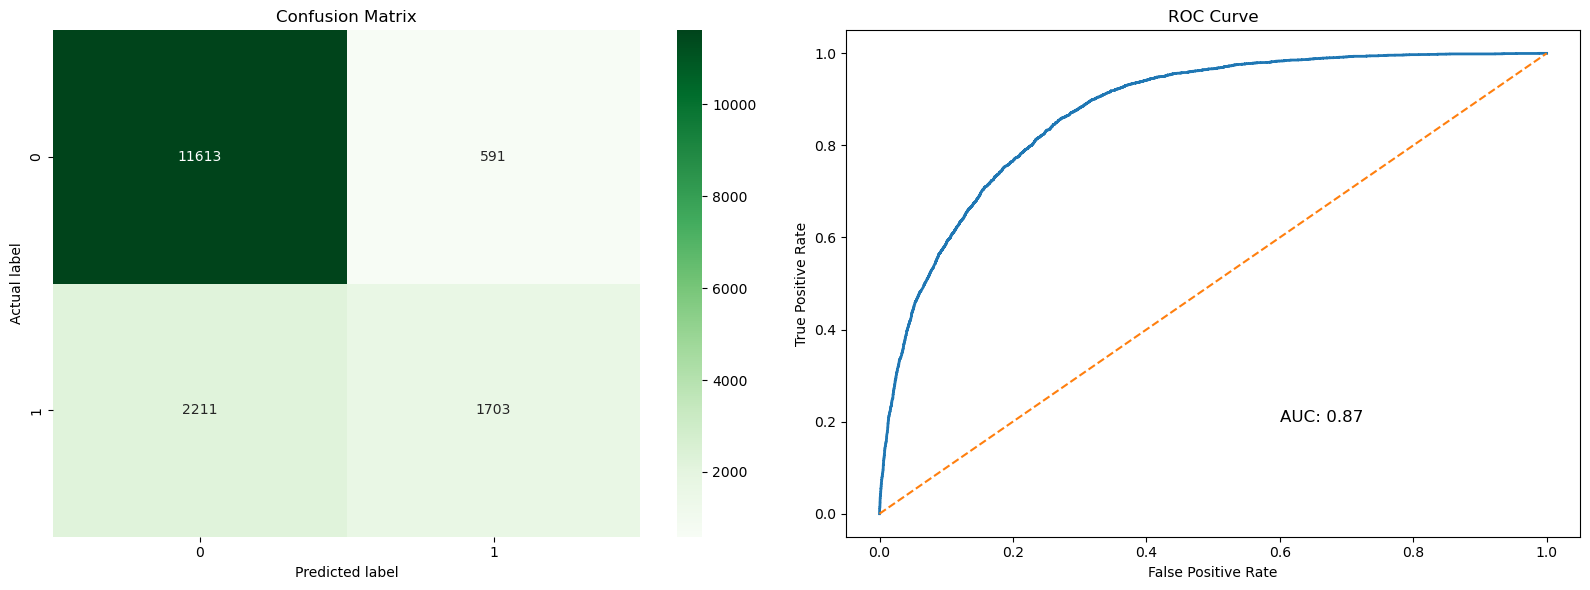


Test Set Performance of Support Vector Classifier:
Accuracy : 0.8262
Precision: 0.7424
Recall   : 0.4351
F1 Score : 0.5486
ROC AUC  : 0.8743
Confusion Matrix:
[[11613   591]
 [ 2211  1703]]


In [558]:
print('Support Vector Classifier')

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Model
model_svc = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True)

# Train
model_svc.fit(X_train, y_train)

# Predictions
Y_pred = model_svc.predict(X_test)

# Scores
train_score = model_svc.score(X_train, y_train)
print('Training Score:', train_score)

test_score = model_svc.score(X_test, y_test)
print('Testing Score:', test_score)

# Classification report
print(classification_report(y_test, Y_pred))

# ------------------ Plots ------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix
cm = confusion_matrix(y_test, Y_pred)
sns.heatmap(pd.DataFrame(cm), annot=True, fmt='g', cmap='Greens', ax=axes[0])

axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted label')
axes[0].set_ylabel('Actual label')

# ROC Curve
y_probabilities = model_svc.predict_proba(X_test)[:, 1]
fpr, tpr, threshold = roc_curve(y_test, y_probabilities)

axes[1].plot(fpr, tpr, linewidth=2)
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')

# AUC
auc_score = roc_auc_score(y_test, y_probabilities)
axes[1].text(0.6, 0.2, f'AUC: {auc_score:.2f}', fontsize=12)

plt.tight_layout()
plt.show()

# ------------------ Metrics ------------------

y_pred = Y_pred
y_proba = y_probabilities

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("\nTest Set Performance of Support Vector Classifier:")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")

cm = confusion_matrix(y_test, Y_pred)
print("Confusion Matrix:")
print(cm)


<p style="font-family: Cambria; font-size: 22px;"><b>Support Vector Classifier (SVC)
 
Model Performance Summary:
    
* Accuracy (82.62%): The model correctly classifies income for over 82% of individuals in the test set.
* Precision for >50K (74.24%): Good precision for high-income predictions.
* Recall for >50K (43.51%): Low recall → misses many actual high earners.
* F1 Score (54.86%): Lower balance due to poor recall.
* ROC AUC (87.43%): Good separation capability.

Confusion Matrix Interpretation:
    
* True Negatives (11613): Strong at identifying low-income individuals.
* True Positives (1703): Lower detection of high earners.
* False Positives (591): Controlled false positives.
* False Negatives (2211): Highest among models → many missed high earners.

Key Insights:
    
* High precision but very low recall.
* Not ideal when detecting high-income individuals is critical.
* Computationally expensive for large datasets.

<p style="font-family: Cambria; text-align: center; font-size: 48px;">XGBoost (eXtreme Gradient Boosting)

<p style="font-family: Cambria; font-size: 22px;"><b> 
It is a powerful, optimized, and distributed gradient boosting library. It's a popular choice for both regression
and classification tasks, known for its high accuracy and speed. XGBoost builds predictive models by combining the predictions of multiple weak learners, often decision trees, in an iterative manner.

In [ ]:
!pip install xgboost

Gradient Boosting Classifier (XGBoost)


C:\Users\Sitab\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [02:31:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training Score: 0.8688729984109522
Testing Score: 0.8647474872813005
              precision    recall  f1-score   support

           0       0.88      0.95      0.91     12204
           1       0.80      0.59      0.68      3914

    accuracy                           0.86     16118
   macro avg       0.84      0.77      0.80     16118
weighted avg       0.86      0.86      0.86     16118



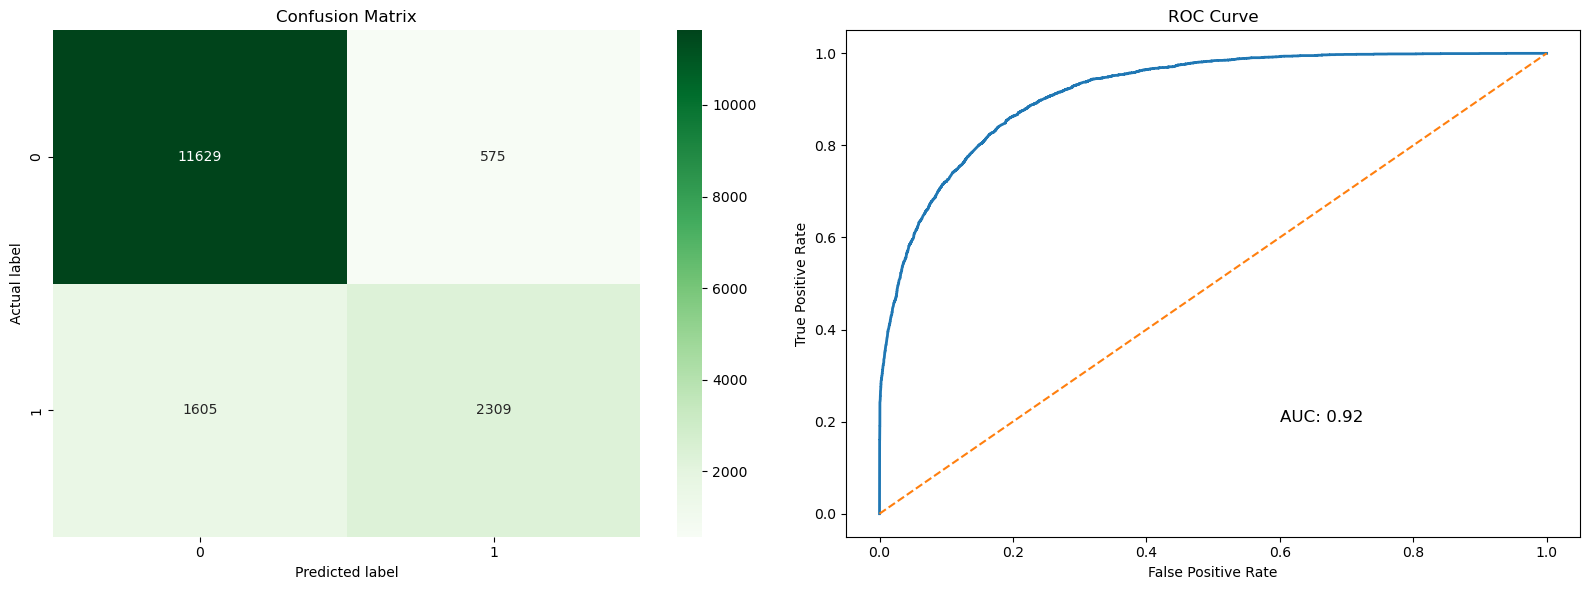


Test Set Performance of XGBoost:
Accuracy : 0.8647
Precision: 0.8006
Recall   : 0.5899
F1 Score : 0.6793
ROC AUC  : 0.9173
Confusion Matrix:
[[11629   575]
 [ 1605  2309]]


In [552]:
print('Gradient Boosting Classifier (XGBoost)')

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix, roc_curve

# Model (your parameters)
model_xgb = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=3,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Train
model_xgb.fit(X_train, y_train)

# Predictions
Y_pred = model_xgb.predict(X_test)

# Scores
train_score = model_xgb.score(X_train, y_train)
print('Training Score:', train_score)

test_score = model_xgb.score(X_test, y_test)
print('Testing Score:', test_score)   # ✅ fixed print

# Classification report
print(classification_report(y_test, Y_pred))

# ------------------ Plots ------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix
cm = confusion_matrix(y_test, Y_pred)
sns.heatmap(pd.DataFrame(cm), annot=True, fmt='g', cmap='Greens', ax=axes[0])

axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted label')
axes[0].set_ylabel('Actual label')

# ROC Curve
y_probabilities = model_xgb.predict_proba(X_test)[:, 1]
fpr, tpr, threshold = roc_curve(y_test, y_probabilities)

axes[1].plot(fpr, tpr, linewidth=2)
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')

# AUC
auc_score = roc_auc_score(y_test, y_probabilities)
axes[1].text(0.6, 0.2, f'AUC: {auc_score:.2f}', fontsize=12)

plt.tight_layout()
plt.show()

# ------------------ Metrics ------------------

y_pred = Y_pred
y_proba = y_probabilities

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("\nTest Set Performance of XGBoost:")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")

cm = confusion_matrix(y_test, Y_pred)
print("Confusion Matrix:")
print(cm)


<p style="font-family: Cambria; font-size: 22px;"><b> XGBoost
 
Model Performance Summary:
    
* Accuracy (86.47%): The model correctly predicts income class for over 86% of individuals in the test set.
* Precision for >50K (80.06%): Best precision → very reliable predictions.
* Recall for >50K (58.99%):The model identifies nearly 59% of people who actually earn >50K, showing good ability to catch high earners.
* F1 Score (67.93%): A good balance of precision and recall for the >50K class.
* ROC AUC (91.73%): Very strong class separation, indicating the model can effectively distinguish between high and low income groups.

Confusion Matrix Interpretation:

* True Negatives (11629): Excellent low-income classification.
* True Positives (2309): Highest detection of high earners.
* False Positives (575): Lowest false positives → very precise.
* False Negatives (1605): Lowest missed high earners among models.

Key Insights:

* Best overall model with balanced performance.
* Captures complex patterns and feature interactions effectively.
* Strong generalization with reduced overfitting.

<p style="font-family: Cambria; text-align: center; font-size: 35px;"> Model comparison and Insights

In [584]:
import pandas as pd
from tabulate import tabulate

# Create DataFrame (numeric values)
data = {
    "Model": [
        "Logistic Regression", "XGBoost", "Random Forest", "SVC"
    ],
    "Accuracy": [0.8244, 0.8647, 0.8567, 0.8262],
    "Precision": [0.6804, 0.8006, 0.7882, 0.7424],
    "Recall": [0.5217, 0.5899, 0.5608, 0.4351],
    "F1 Score": [0.5906, 0.6793, 0.6553, 0.5486],
    "ROC AUC": [0.8752, 0.9173, 0.9106, 0.8743]
}

df = pd.DataFrame(data)

#  Step 1: Sort BEFORE converting
df_sorted = df.sort_values('F1 Score', ascending=False)

# Step 2: Convert to percentage for display
metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"]
df_display = df_sorted.copy()
df_display[metrics] = df_display[metrics].applymap(lambda x: f"{x * 100:.2f}%")

# Styled table 
styled = df_sorted.style.background_gradient(
    cmap='Greens',
    subset=metrics
)

# Print formatted table
print(tabulate(df_display, headers='keys', tablefmt='fancy_grid', showindex=False))


╒═════════════════════╤════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ Model               │ Accuracy   │ Precision   │ Recall   │ F1 Score   │ ROC AUC   │
╞═════════════════════╪════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ XGBoost             │ 86.47%     │ 80.06%      │ 58.99%   │ 67.93%     │ 91.73%    │
├─────────────────────┼────────────┼─────────────┼──────────┼────────────┼───────────┤
│ Random Forest       │ 85.67%     │ 78.82%      │ 56.08%   │ 65.53%     │ 91.06%    │
├─────────────────────┼────────────┼─────────────┼──────────┼────────────┼───────────┤
│ Logistic Regression │ 82.44%     │ 68.04%      │ 52.17%   │ 59.06%     │ 87.52%    │
├─────────────────────┼────────────┼─────────────┼──────────┼────────────┼───────────┤
│ SVC                 │ 82.62%     │ 74.24%      │ 43.51%   │ 54.86%     │ 87.43%    │
╘═════════════════════╧════════════╧═════════════╧══════════╧════════════╧═══════════╛


C:\Users\Sitab\AppData\Local\Temp\ipykernel_28740\3610818069.py:24: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_display[metrics] = df_display[metrics].applymap(lambda x: f"{x * 100:.2f}%")


## Detailed Insights

### 1. Logistic Regression
**Strengths:** Simple, interpretable, and stable baseline.  
**Weaknesses:** Lower recall → misses many high-income individuals.  
**Use Case:** When interpretability and speed are priorities.  



### 2. XGBoost
**Strengths:** Best F1 Score and ROC AUC; strong precision and recall balance.  
**Weaknesses:** Slightly more complex and computationally heavier.  
**Use Case:** Best overall choice for accurate and robust predictions.  



### 3. Random Forest
**Strengths:** High precision and strong accuracy; robust to noise.  
**Weaknesses:** Slightly lower recall than XGBoost.  
**Bias-Variance:** Low bias, moderate variance.  
**Use Case:** When reducing false positives is important.  



### 4. Support Vector Classifier
**Strengths:** Good precision and solid decision boundaries.  
**Weaknesses:** Very low recall → misses many positives.  
**Use Case:** Smaller datasets with clear margins.  

### Final Recommendation & Insights

**Best Model:** XGBoost  
**Reasons:**
-Highest F1 Score (67.93%) and ROC AUC (91.73%)  
-Best balance between precision and recall  
-Lowest false positives and false negatives among models  

**Trade-offs:**
-Logistic Regression → better interpretability but lower recall    
Random Forest → strong precision but slightly lower recall    
SVC → high precision but poor recall  

**Use Case Guidance:**

-If recall is critical → Logistic Regression  
-If precision is critical → Random Forest  
-If overall performance matters → XGBoost (best choice)